# Wireless Networking and Mobile Computing

### Prerequisites
This Jupyter Notebook has been tested with Visual Studio Code, running in a local Python environment.

**Installs**

In [1]:
# --- Installs: ensure required packages are available ---
%pip install matplotlib pandas scipy --quiet

Note: you may need to restart the kernel to use updated packages.


**Imports**


In [2]:
# --- Imports: libraries used in this notebook ---
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path


**Declarations**

Set the variables below and run the generation cell.

- `csv_files` lists files containing either one numeric sample column or a Jemula result CSV.
- Jemula files are read from their named interval measurement column; the time column is never included in the statistics.
- If a CSV has several possible measurement columns, set its exact column name in `measurement_columns`, for example `{"my_data.csv": "measurement"}`.
- `confidence_level` defines the confidence level (e.g., 0.95 for a 95% interval).


In [3]:
# --- Declarations: editable variables for students ---
csv_files = [
    '../01 Jemula/jemula-project/results/Jemula802_GettingStarted_EiffelTower/total_thrp.csv',
]

# Optional: choose an exact CSV column when a file has multiple measurements.
# Keys may be the full path in csv_files or just the file name.
measurement_columns = {}

confidence_level = 0.95


### 1. Introduction

#### 1.1 Definition

A confidence interval (CI) expresses **uncertainty around an estimated parameter**, such as the sample mean. A 95% confidence interval is produced by a procedure that would cover the true population mean in about 95% of repeated samples.

For a sample with unknown population standard deviation, the two-sided Student's t interval for the mean is

$$
\bar{x} \pm t_{1-\alpha/2,\,n-1} \frac{s}{\sqrt{n}},
$$

where
- $\bar{x}$ is the sample mean
- $s$ is the sample standard deviation
- $n$ is the number of valid observations
- $t_{1-\alpha/2,\,n-1}$ is the Student's t critical value for confidence level $1-\alpha$ and $n-1$ degrees of freedom (for a 95% interval, it approaches 1.96 as $n$ grows)


In [4]:
# --- Load Data ---
def _is_numeric(value):
    try:
        float(value)
    except (TypeError, ValueError):
        return False
    return True


def _time_column(frame):
    for column in frame.columns:
        name = str(column).strip().lower()
        if name == "time" or name.startswith(("time[", "time [")):
            return column
    return None


def read_numeric_series(path, column=None):
    """Read one measurement column from a simple or Jemula CSV."""
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"CSV file not found: {path}")

    with path.open("r", encoding="utf-8-sig", newline="") as source:
        first_row = next((row for row in csv.reader(source) if row), None)
    if first_row is None:
        raise ValueError(f"CSV file is empty: {path}")

    headerless = all(_is_numeric(value) for value in first_row)
    frame = pd.read_csv(path, header=None if headerless else 0, encoding="utf-8-sig")
    if headerless:
        frame.columns = [f"column_{index + 1}" for index in range(frame.shape[1])]
    else:
        frame.columns = [str(name).strip() for name in frame.columns]
    if frame.empty:
        raise ValueError(f"CSV file has a header but no data rows: {path}")

    columns = {str(name).strip().lower(): name for name in frame.columns}
    if column is not None:
        selected = columns.get(str(column).strip().lower())
        if selected is None:
            raise ValueError(
                f"Column {column!r} is not in {path}. Available columns: {list(frame.columns)}"
            )
    else:
        filename = path.name.lower()
        preferred_columns = (
            ("delay", "avrg last interval [ms]"),
            ("offer", "offer last interval [mb/s]"),
            ("thrp", "thrp last interval [mb/s]"),
            ("throughput", "thrp last interval [mb/s]"),
        )
        preferred = next((name for hint, name in preferred_columns if hint in filename), None)
        selected = columns.get(preferred)

        if selected is None:
            time_column = _time_column(frame)
            numeric_columns = [
                name for name in frame.columns
                if name != time_column
                and pd.to_numeric(frame[name], errors="coerce").notna().any()
            ]
            if len(numeric_columns) == 1:
                selected = numeric_columns[0]
            elif not numeric_columns:
                raise ValueError(f"No numeric measurement column found in {path}.")
            else:
                raise ValueError(
                    f"Several numeric measurements are available in {path}: {numeric_columns}. "
                    "Set measurement_columns for this file to the exact column name."
                )

    column_name = str(selected).strip()
    values = pd.to_numeric(frame[selected], errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(values)
    time_column = _time_column(frame)
    if time_column is not None and "last interval" in column_name.lower():
        times = pd.to_numeric(frame[time_column], errors="coerce").to_numpy(dtype=float)
        # The first last-interval row has no preceding interval.
        valid &= np.isfinite(times) & (times > 0)

    samples = values[valid]
    if samples.size == 0:
        raise ValueError(f"No finite samples found in column {column_name!r} of {path}.")
    unit = (
        column_name.rsplit("[", 1)[1].split("]", 1)[0].strip()
        if "[" in column_name and "]" in column_name
        else "CSV units"
    )
    return samples, column_name, unit


if not 0 < confidence_level < 1:
    raise ValueError("confidence_level must be between 0 and 1, for example 0.95")

# Store one one-dimensional sample series per file.
datasets = {}
dataset_columns = {}
dataset_units = {}

for path in csv_files:
    dataset_name = Path(path).stem
    if dataset_name in datasets:
        dataset_name = f"{Path(path).parent.name}/{dataset_name}"

    selected_column = measurement_columns.get(path)
    if selected_column is None:
        selected_column = measurement_columns.get(str(path))
    if selected_column is None:
        selected_column = measurement_columns.get(Path(path).name)
    try:
        samples, column_name, unit = read_numeric_series(path, column=selected_column)
        datasets[dataset_name] = samples
        dataset_columns[dataset_name] = column_name
        dataset_units[dataset_name] = unit
        print(f"Loaded {dataset_name}: {len(samples)} finite samples from '{column_name}'")
    except Exception as error:
        raise ValueError(f"Could not load {path}: {error}") from error

if not datasets:
    raise ValueError("No CSV datasets were loaded. Add at least one path to csv_files.")


Loaded total_thrp: 1200 finite samples from 'thrp last interval [Mb/s]'


In [5]:
# --- Compute Confidence Intervals ---
results = []

for name, data in datasets.items():
    n = len(data)
    if n < 2:
        raise ValueError(f"{name} has only {n} valid sample(s); at least two are needed for a t confidence interval.")

    mean = np.mean(data)
    std = np.std(data, ddof=1)  # sample standard deviation
    standard_error = std / np.sqrt(n)
    if standard_error == 0:
        # A constant sample has zero estimated uncertainty; some SciPy versions
        # return NaN for a zero-scale t distribution.
        ci_low, ci_high = mean, mean
    else:
        ci_low, ci_high = stats.t.interval(
            confidence_level, df=n - 1, loc=mean, scale=standard_error
        )

    results.append({
        'Dataset': name,
        'Column': dataset_columns[name],
        'Unit': dataset_units[name],
        'N': n,
        'Mean': mean,
        'StdDev': std,
        'StandardError': standard_error,
        'CI_Lower': ci_low,
        'CI_Upper': ci_high,
    })

    print(f"\nDataset: {name}")
    print(f" - Column:  {dataset_columns[name]}")
    print(f" - n:       {n}")
    print(f" - Mean:    {mean:.6g} {dataset_units[name]}")
    print(f" - StdDev:  {std:.6g} {dataset_units[name]}")
    print(f" - SE:      {standard_error:.6g} {dataset_units[name]}")
    print(f" - {confidence_level:.0%} t CI: [{ci_low:.6g}, {ci_high:.6g}] {dataset_units[name]}")

df_results = pd.DataFrame(results)



Dataset: total_thrp
 - Column:  thrp last interval [Mb/s]
 - n:       1200
 - Mean:    3.98744 Mb/s
 - StdDev:  0.200626 Mb/s
 - SE:      0.00579156 Mb/s
 - 95% t CI: [3.97608, 3.99881] Mb/s


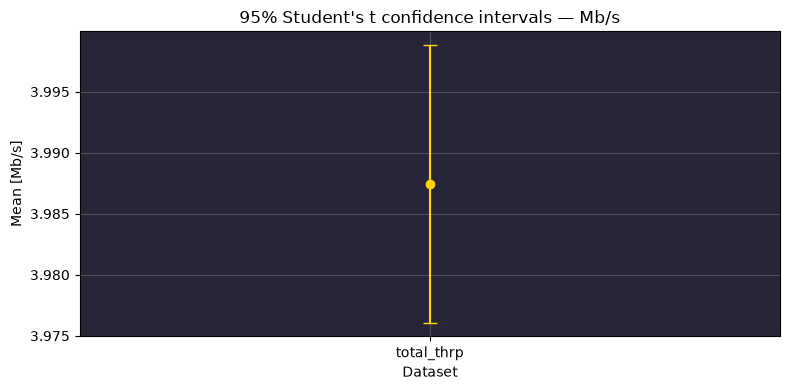

In [6]:
# --- Plot Confidence Intervals per Dataset ---
units = list(dict.fromkeys(df_results['Unit']))
fig, axes = plt.subplots(len(units), 1, figsize=(8, 4 * len(units)), squeeze=False)
colors = ['gold', 'lime', 'cyan']

for ax, unit in zip(axes.flat, units):
    unit_results = df_results[df_results['Unit'] == unit].reset_index(drop=True)
    ax.set_facecolor((0.15, 0.15, 0.22))
    for i, row in unit_results.iterrows():
        ax.errorbar(
            i,
            row['Mean'],
            yerr=[[row['Mean'] - row['CI_Lower']], [row['CI_Upper'] - row['Mean']]],
            fmt='o',
            color=colors[i % len(colors)],
            capsize=5,
        )

    ax.set_xticks(range(len(unit_results)))
    ax.set_xticklabels(unit_results['Dataset'])
    ax.set_title(f"{confidence_level:.0%} Student's t confidence intervals — {unit}")
    ax.set_xlabel('Dataset')
    ax.set_ylabel(f'Mean [{unit}]')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### 1.2 Usage

Confidence intervals can be computed **whenever repeated or random samples** are available and the data represent independent observations from a population. They assume the sampling distribution of the mean is approximately normal, which is valid either when the population itself is normal or when the sample size is sufficiently large (Central Limit Theorem).

For Jemula CSVs, the reader uses the named **last interval** throughput, offer, or average-delay field and excludes the time-zero bookkeeping row. Consecutive simulation intervals can be correlated, so the usual Student's t interval is an approximation unless the samples are sufficiently independent. Exclude warm-up periods when choosing or preparing the data.

#### 1.3 Interpretation
- The mean gives a point estimate of the central tendency.
- The confidence interval quantifies uncertainty: a wider CI means more variability or fewer samples.
- Increasing sample size or lowering variability tightens the CI.
